In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
# PHASE 1: SETUP & DATA CONSOLIDATION

In [1]:
!pip install -q optuna

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.metrics import mean_absolute_error, mean_squared_error, f1_score
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb
from statsmodels.tsa.api import VAR
import optuna
import os, warnings, copy
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

os.makedirs('/kaggle/working/figures', exist_ok=True)

Using device: cuda


In [3]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/tushardobal/india-city-air-quality-index-dataset-20152023/india_city_aqi_2015_2023.csv


In [4]:
# Load data

DATA_PATH = '/kaggle/input/datasets/tushardobal/india-city-air-quality-index-dataset-20152023/india_city_aqi_2015_2023.csv'

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

REQUIRED_COLS = ['City', 'Date', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'AQI', 'AQI_Bucket']
missing = [c for c in REQUIRED_COLS if c not in df.columns]
if missing:
    print('WARNING - missing expected columns:', missing)
    print('Available columns:', list(df.columns))

(32870, 10)
WARNING - missing expected columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'AQI', 'AQI_Bucket']
Available columns: ['city', 'date', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'aqi', 'aqi_category']


In [5]:
DATA_PATH = '/kaggle/input/datasets/tushardobal/india-city-air-quality-index-dataset-20152023/india_city_aqi_2015_2023.csv'

df = pd.read_csv(DATA_PATH)

# --- Rename to match the rest of the notebook ---
df = df.rename(columns={
    'city': 'City',
    'date': 'Date',
    'pm25': 'PM2.5',
    'pm10': 'PM10',
    'no2': 'NO2',
    'so2': 'SO2',
    'co': 'CO',
    'o3': 'O3',
    'aqi': 'AQI',
    'aqi_category': 'AQI_Bucket'
})

print(df.shape)
df.head()

REQUIRED_COLS = ['City', 'Date', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'AQI', 'AQI_Bucket']
missing = [c for c in REQUIRED_COLS if c not in df.columns]
if missing:
    print('WARNING - missing expected columns:', missing)
    print('Available columns:', list(df.columns))
else:
    print('All required columns present ✓')

print('\nUnique AQI_Bucket values:', df['AQI_Bucket'].unique())

(32870, 10)
All required columns present ✓

Unique AQI_Bucket values: ['Moderate' 'Satisfactory' 'Good' 'Poor']


In [6]:
# Preprocessing: missing-value thresholding + imputation (Phase 1 of roadmap)
POLLUTANTS = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']

df['Date'] = pd.to_datetime(df['Date'])

# --- Missing Value Thresholding: drop stations with >30% missing pollutant records ---
missing_frac = df.groupby('City')[POLLUTANTS].apply(lambda x: x.isna().mean().mean())
valid_cities = missing_frac[missing_frac <= 0.30].index.tolist()
print(f'Kept {len(valid_cities)} / {df.City.nunique()} cities after 30% missingness filter')

df = df[df['City'].isin(valid_cities)].copy()

# --- AQI category -> integer class ---
# NOTE: standard CPCB buckets are 6 (Good..Severe), but this dataset only contains 4.
# We build CATEGORY_ORDER dynamically from whatever categories actually exist in the data,
# in the correct severity order, so nothing breaks if your dataset has a different subset.
FULL_SEVERITY_ORDER = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
present_categories = set(df['AQI_Bucket'].dropna().unique().tolist())
CATEGORY_ORDER = [c for c in FULL_SEVERITY_ORDER if c in present_categories]
N_CLASSES = len(CATEGORY_ORDER)
print('Using', N_CLASSES, 'AQI classes:', CATEGORY_ORDER)

cat_map = {c: i for i, c in enumerate(CATEGORY_ORDER)}
df['AQI_Class'] = df['AQI_Bucket'].map(cat_map)

# --- Pivot into a city x date x pollutant tensor ---
pivot = df.pivot_table(index='Date', columns='City', values=POLLUTANTS + ['AQI', 'AQI_Class'])
pivot = pivot.sort_index()

# --- Spatio-Temporal Imputation (linear interpolation as a practical stand-in for MICE) ---
pivot = pivot.interpolate(method='linear', limit_direction='both')
pivot = pivot.ffill().bfill()

cities = sorted(valid_cities)
M = len(cities)          # number of monitoring stations/nodes
P = len(POLLUTANTS)      # number of pollutants
print('Cities (M):', M, '| Pollutants (P):', P, '| Days:', len(pivot))

Kept 10 / 10 cities after 30% missingness filter
Using 4 AQI classes: ['Good', 'Satisfactory', 'Moderate', 'Poor']
Cities (M): 10 | Pollutants (P): 6 | Days: 3287


In [7]:
# Build tensors  X: [T, M, P]   AQI: [T, M]   Class: [T, M]
T_total = len(pivot)

X = np.zeros((T_total, M, P), dtype=np.float32)
for pi, pol in enumerate(POLLUTANTS):
    X[:, :, pi] = pivot[pol][cities].values

Y_reg = pivot['AQI'][cities].values.astype(np.float32)
Y_cls = pivot['AQI_Class'][cities].fillna(0).values.astype(np.int64)
Y_cls = np.clip(Y_cls, 0, N_CLASSES - 1)

print('X shape:', X.shape, '| Y_reg shape:', Y_reg.shape, '| Y_cls shape:', Y_cls.shape)

X shape: (3287, 10, 6) | Y_reg shape: (3287, 10) | Y_cls shape: (3287, 10)


In [8]:
# Windowing + time-based train/val/test split (avoids temporal leakage)
H = 14          # lookback window (days)
F_HORIZON = 3   # forecast horizon (days)

def make_windows(X, Yr, Yc, H, F_HORIZON):
    T = X.shape[0]
    Xs, Yrs, Ycs = [], [], []
    for t in range(H, T - F_HORIZON):
        Xs.append(X[t-H:t])
        Yrs.append(Yr[t:t+F_HORIZON])
        Ycs.append(Yc[t:t+F_HORIZON])
    return np.stack(Xs), np.stack(Yrs), np.stack(Ycs)

n = T_total
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train_raw, Yr_train_raw, Yc_train_raw = X[:train_end], Y_reg[:train_end], Y_cls[:train_end]
X_val_raw, Yr_val_raw, Yc_val_raw = X[train_end:val_end], Y_reg[train_end:val_end], Y_cls[train_end:val_end]
X_test_raw, Yr_test_raw, Yc_test_raw = X[val_end:], Y_reg[val_end:], Y_cls[val_end:]

mu = X_train_raw.reshape(-1, P).mean(axis=0)
sigma = X_train_raw.reshape(-1, P).std(axis=0) + 1e-6
aqi_mu, aqi_sigma = Yr_train_raw.mean(), Yr_train_raw.std() + 1e-6

def normalize(Xr, Yr):
    return (Xr - mu) / sigma, (Yr - aqi_mu) / aqi_sigma

X_train_n, Yr_train_n = normalize(X_train_raw, Yr_train_raw)
X_val_n, Yr_val_n = normalize(X_val_raw, Yr_val_raw)
X_test_n, Yr_test_n = normalize(X_test_raw, Yr_test_raw)

Xtr, Yrtr, Yctr = make_windows(X_train_n, Yr_train_n, Yc_train_raw, H, F_HORIZON)
Xva, Yrva, Ycva = make_windows(X_val_n, Yr_val_n, Yc_val_raw, H, F_HORIZON)
Xte, Yrte, Ycte = make_windows(X_test_n, Yr_test_n, Yc_test_raw, H, F_HORIZON)

print('Train windows:', Xtr.shape, '| Val windows:', Xva.shape, '| Test windows:', Xte.shape)

Train windows: (2283, 14, 10, 6) | Val windows: (476, 14, 10, 6) | Test windows: (477, 14, 10, 6)


In [10]:
# Dataset / DataLoader
class AQIDataset(Dataset):
    def __init__(self, X, Yr, Yc):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Yr = torch.tensor(Yr, dtype=torch.float32)
        self.Yc = torch.tensor(Yc, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.Yr[idx], self.Yc[idx]

BATCH_SIZE = 16

train_ds = AQIDataset(Xtr, Yrtr, Yctr)
val_ds = AQIDataset(Xva, Yrva, Ycva)
test_ds = AQIDataset(Xte, Yrte, Ycte)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
# Shared metric utilities (MAE, RMSE, SMAPE, Macro-F1)
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom = np.where(denom == 0, 1e-6, denom)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    sm = smape(y_true, y_pred)
    return mae, rmse, sm

results_table = []   # collects {'Model': ..., 'MAE': ..., 'RMSE': ..., 'SMAPE': ..., 'MacroF1': ...}

In [14]:
# Baseline 1: XGBoost — non-linear local point features
# Flatten each [H, M, P] window into a feature vector; predict AQI for a representative city
# (city-averaged) across the F-step horizon.
city_idx_for_baseline = 0  # pick first city as representative point-forecast target

Xtr_flat = Xtr.reshape(len(Xtr), -1)
Xte_flat = Xte.reshape(len(Xte), -1)
Ytr_city = Yrtr[:, :, city_idx_for_baseline]
Yte_city = Yrte[:, :, city_idx_for_baseline]

xgb_model = MultiOutputRegressor(xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                                                    n_jobs=-1, random_state=SEED))
xgb_model.fit(Xtr_flat, Ytr_city)
xgb_pred = xgb_model.predict(Xte_flat)

xgb_pred_denorm = xgb_pred * aqi_sigma + aqi_mu
xgb_true_denorm = Yte_city * aqi_sigma + aqi_mu

mae, rmse, sm = regression_metrics(xgb_true_denorm.flatten(), xgb_pred_denorm.flatten())
results_table.append({'Model': 'XGBoost', 'MAE': mae, 'RMSE': rmse, 'SMAPE': sm, 'MacroF1': np.nan})
print(f'XGBoost | MAE {mae:.2f} | RMSE {rmse:.2f} | SMAPE {sm:.2f}')

XGBoost | MAE 26.09 | RMSE 32.23 | SMAPE 30.63


In [15]:
# Baseline 2: Bidirectional LSTM with Attention — sequential dependencies
class BiLSTMAttention(nn.Module):
    def __init__(self, P, M, hidden=64, F_horizon=3, n_classes=6):
        super().__init__()
        self.input_proj = nn.Linear(M * P, hidden)
        self.lstm = nn.LSTM(hidden, hidden, batch_first=True, bidirectional=True)
        self.attn_score = nn.Linear(hidden * 2, 1)
        self.reg_head = nn.Linear(hidden * 2, F_horizon * M)
        self.cls_head = nn.Linear(hidden * 2, F_horizon * M * n_classes)
        self.F_horizon, self.M, self.n_classes = F_horizon, M, n_classes

    def forward(self, x):
        B, T, M, P = x.shape
        x = x.reshape(B, T, M * P)
        x = self.input_proj(x)
        out, _ = self.lstm(x)                       # [B, T, 2*hidden]
        scores = F.softmax(self.attn_score(out), dim=1)
        context = (scores * out).sum(dim=1)          # [B, 2*hidden]
        reg = self.reg_head(context).reshape(B, self.F_horizon, self.M)
        cls = self.cls_head(context).reshape(B, self.F_horizon, self.M, self.n_classes)
        return reg, cls

def train_simple_model(model, train_loader, val_loader, n_epochs, lr=1e-3, lambda1=1.0, lambda2=1.0, tag='model'):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(n_epochs):
        model.train()
        for xb, yrb, ycb in train_loader:
            xb, yrb, ycb = xb.to(device), yrb.to(device), ycb.to(device)
            opt.zero_grad()
            reg_out, cls_out = model(xb)
            mse = F.mse_loss(reg_out, yrb)
            ce = F.cross_entropy(cls_out.reshape(-1, cls_out.shape[-1]), ycb.reshape(-1))
            loss = lambda1 * mse + lambda2 * ce
            loss.backward()
            opt.step()
    return model

def eval_simple_model(model, loader):
    model.eval()
    all_reg_pred, all_reg_true, all_cls_pred, all_cls_true = [], [], [], []
    with torch.no_grad():
        for xb, yrb, ycb in loader:
            xb = xb.to(device)
            reg_out, cls_out = model(xb)
            all_reg_pred.append(reg_out.cpu().numpy())
            all_reg_true.append(yrb.numpy())
            all_cls_pred.append(cls_out.argmax(-1).cpu().numpy())
            all_cls_true.append(ycb.numpy())
    reg_pred = np.concatenate(all_reg_pred).flatten() * aqi_sigma + aqi_mu
    reg_true = np.concatenate(all_reg_true).flatten() * aqi_sigma + aqi_mu
    cls_pred = np.concatenate(all_cls_pred).flatten()
    cls_true = np.concatenate(all_cls_true).flatten()
    mae, rmse, sm = regression_metrics(reg_true, reg_pred)
    f1 = f1_score(cls_true, cls_pred, average='macro')
    return mae, rmse, sm, f1

bilstm_model = BiLSTMAttention(P, M, hidden=64, F_horizon=F_HORIZON, n_classes=N_CLASSES)
bilstm_model = train_simple_model(bilstm_model, train_loader, val_loader, n_epochs=30, tag='bilstm')
mae, rmse, sm, f1 = eval_simple_model(bilstm_model, test_loader)
results_table.append({'Model': 'BiLSTM+Attention', 'MAE': mae, 'RMSE': rmse, 'SMAPE': sm, 'MacroF1': f1})
print(f'BiLSTM+Attention | MAE {mae:.2f} | RMSE {rmse:.2f} | SMAPE {sm:.2f} | F1 {f1:.3f}')

BiLSTM+Attention | MAE 30.23 | RMSE 37.46 | SMAPE 35.86 | F1 0.246


In [16]:
# Baseline 3: Simplified STGCN — spatial graph + temporal convolution (no attention)
# Reuses the adaptive-adjacency idea but replaces the transformer with a plain 1D temporal conv,
# matching the "Spatio-Temporal GNN" family (STGCN/DCRNN) in the roadmap's baseline taxonomy.
class SimplifiedSTGCN(nn.Module):
    def __init__(self, P, M, d_model=32, F_horizon=3, n_classes=6, embed_dim=16):
        super().__init__()
        self.linear_in = nn.Linear(P, d_model)
        self.node_embed = nn.Parameter(torch.randn(M, embed_dim) * 0.01)
        self.gcn_weight = nn.Linear(d_model, d_model)
        self.temporal_conv = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1)
        self.reg_head = nn.Linear(d_model, F_horizon)
        self.cls_head = nn.Linear(d_model, F_horizon * n_classes)
        self.F_horizon, self.n_classes = F_horizon, n_classes

    def forward(self, x):
        B, T, M, P = x.shape
        h = F.relu(self.linear_in(x))                      # [B, T, M, d]
        adj = F.softmax(F.relu(self.node_embed @ self.node_embed.T), dim=-1)
        h_flat = h.reshape(B * T, M, -1)
        msg = torch.einsum('mn,bnd->bmd', adj, h_flat).reshape(B, T, M, -1)
        h = F.relu(self.gcn_weight(msg))                     # [B, T, M, d]
        h = h.permute(0, 2, 3, 1).reshape(B * M, -1, T)       # [B*M, d, T]
        h = F.relu(self.temporal_conv(h))
        pooled = h.mean(dim=-1).reshape(B, M, -1)             # temporal pooling
        reg = self.reg_head(pooled).permute(0, 2, 1)
        cls = self.cls_head(pooled).reshape(B, M, self.F_horizon, self.n_classes).permute(0, 2, 1, 3)
        return reg, cls

stgcn_model = SimplifiedSTGCN(P, M, F_horizon=F_HORIZON, n_classes=N_CLASSES)
stgcn_model = train_simple_model(stgcn_model, train_loader, val_loader, n_epochs=30, tag='stgcn')
mae, rmse, sm, f1 = eval_simple_model(stgcn_model, test_loader)
results_table.append({'Model': 'Simplified STGCN', 'MAE': mae, 'RMSE': rmse, 'SMAPE': sm, 'MacroF1': f1})
print(f'Simplified STGCN | MAE {mae:.2f} | RMSE {rmse:.2f} | SMAPE {sm:.2f} | F1 {f1:.3f}')

Simplified STGCN | MAE 26.06 | RMSE 32.17 | SMAPE 31.35 | F1 0.171


In [18]:
# Baseline 4: Simplified PatchTST-style Transformer — long-horizon structural dependencies
# Same temporal patch-transformer used inside ST-MPFT, but with NO chemical attention and
# NO spatial graph — representing the "SOTA pure-transformer" baseline family
# (PatchTST / Informer / iTransformer) from the roadmap.
class PatchTransformerBlock(nn.Module):
    def __init__(self, T, d_model, patch_len=7, n_heads=4, n_layers=2):
        super().__init__()
        self.patch_len = patch_len
        n_patches = max(1, T // patch_len)
        self.n_patches = n_patches
        self.patch_embed = nn.Linear(patch_len * d_model, d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, n_patches, d_model) * 0.01)
        encoder_layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model*4,
                                                     batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

    def forward(self, x):
        B, T, M, D = x.shape
        usable_T = self.n_patches * self.patch_len
        x = x[:, :usable_T]
        x = x.permute(0, 2, 1, 3).reshape(B * M, self.n_patches, self.patch_len * D)
        patches = self.patch_embed(x) + self.pos_embed
        encoded = self.transformer(patches)
        pooled = encoded.mean(dim=1).reshape(B, M, D)
        return pooled

class SimplifiedPatchTST(nn.Module):
    def __init__(self, P, M, T, d_model=32, F_horizon=3, n_classes=6):
        super().__init__()
        self.linear_in = nn.Linear(P, d_model)
        self.temporal = PatchTransformerBlock(T, d_model)
        self.reg_head = nn.Linear(d_model, F_horizon)
        self.cls_head = nn.Linear(d_model, F_horizon * n_classes)
        self.F_horizon, self.n_classes = F_horizon, n_classes

    def forward(self, x):
        h = F.relu(self.linear_in(x))
        pooled = self.temporal(h)
        reg = self.reg_head(pooled).permute(0, 2, 1)
        B, M, _ = pooled.shape
        cls = self.cls_head(pooled).reshape(B, M, self.F_horizon, self.n_classes).permute(0, 2, 1, 3)
        return reg, cls

patchtst_model = SimplifiedPatchTST(P, M, H, F_horizon=F_HORIZON, n_classes=N_CLASSES)
patchtst_model = train_simple_model(patchtst_model, train_loader, val_loader, n_epochs=30, tag='patchtst')
mae, rmse, sm, f1 = eval_simple_model(patchtst_model, test_loader)
results_table.append({'Model': 'Simplified PatchTST', 'MAE': mae, 'RMSE': rmse, 'SMAPE': sm, 'MacroF1': f1})
print(f'Simplified PatchTST | MAE {mae:.2f} | RMSE {rmse:.2f} | SMAPE {sm:.2f} | F1 {f1:.3f}')

Simplified PatchTST | MAE 26.72 | RMSE 33.05 | SMAPE 32.02 | F1 0.212


In [ ]:
# Phase 2: Proposed ST-MPFT Architecture (Full Model)

In [24]:
# Block 1 - Cross-Pollutant Chemical Attention
class CrossPollutantAttention(nn.Module):
    def __init__(self, P, d_model, n_heads=2):
        super().__init__()
        self.proj_in = nn.Linear(1, d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.out_pool = nn.Linear(P * d_model, d_model)

    def forward(self, x):
        B, T, M, P = x.shape
        x = x.reshape(B * T * M, P, 1)
        tok = self.proj_in(x)
        attn_out, attn_weights = self.attn(tok, tok, tok)
        attn_out = self.norm(attn_out + tok)
        flat = attn_out.reshape(B * T * M, -1)
        out = self.out_pool(flat).reshape(B, T, M, -1)
        return out, attn_weights.reshape(B, T, M, P, P)


# Block 2 - Adaptive Spatial Graph Convolution
class AdaptiveSpatialGCN(nn.Module):
    def __init__(self, M, d_model, embed_dim=16):
        super().__init__()
        self.node_embed = nn.Parameter(torch.randn(M, embed_dim) * 0.01)
        self.gcn_weight = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, M, D = x.shape
        adapt_adj = F.softmax(F.relu(self.node_embed @ self.node_embed.T), dim=-1)
        x_flat = x.reshape(B * T, M, D)
        msg = torch.einsum('mn,bnd->bmd', adapt_adj, x_flat)
        out = F.relu(self.gcn_weight(msg)).reshape(B, T, M, D)
        return out, adapt_adj


# Block 3 - Temporal Patch-Transformer (shared class name reused with new params per instance)
class TemporalPatchTransformer(nn.Module):
    def __init__(self, T, d_model, patch_len=7, n_heads=4, n_layers=2):
        super().__init__()
        self.patch_len = patch_len
        n_patches = max(1, T // patch_len)
        self.n_patches = n_patches
        self.patch_embed = nn.Linear(patch_len * d_model, d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, n_patches, d_model) * 0.01)
        encoder_layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model*4,
                                                     batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

    def forward(self, x):
        B, T, M, D = x.shape
        usable_T = self.n_patches * self.patch_len
        x = x[:, :usable_T]
        x = x.permute(0, 2, 1, 3).reshape(B * M, self.n_patches, self.patch_len * D)
        patches = self.patch_embed(x) + self.pos_embed
        encoded = self.transformer(patches)
        pooled = encoded.mean(dim=1).reshape(B, M, D)
        return pooled


# Full ST-MPFT model with ablation switches built in
class ST_MPFT(nn.Module):
    def __init__(self, P, M, T, d_model=32, F_horizon=3, n_classes=6,
                 patch_len=7, n_heads=4, use_spatial=True, use_chem_attn=True):
        super().__init__()
        self.use_spatial = use_spatial
        self.use_chem_attn = use_chem_attn
        self.F_horizon = F_horizon
        self.n_classes = n_classes

        if use_chem_attn:
            self.chem_attn = CrossPollutantAttention(P, d_model)
        else:
            self.chem_linear = nn.Linear(P, d_model)   # Ablation B fallback

        if use_spatial:
            self.spatial_gcn = AdaptiveSpatialGCN(M, d_model)

        self.temporal_transformer = TemporalPatchTransformer(T, d_model, patch_len=patch_len, n_heads=n_heads)
        self.reg_head = nn.Linear(d_model, F_horizon)
        self.cls_head = nn.Linear(d_model, F_horizon * n_classes)

    def forward(self, x):
        attn_weights, adapt_adj = None, None
        if self.use_chem_attn:
            h, attn_weights = self.chem_attn(x)
        else:
            h = self.chem_linear(x)

        if self.use_spatial:
            h, adapt_adj = self.spatial_gcn(h)

        pooled = self.temporal_transformer(h)
        reg_out = self.reg_head(pooled).permute(0, 2, 1)
        B, M, _ = pooled.shape
        cls_out = self.cls_head(pooled).reshape(B, M, self.F_horizon, self.n_classes).permute(0, 2, 1, 3)
        return reg_out, cls_out, attn_weights, adapt_adj


def multitask_loss(reg_pred, reg_true, cls_pred, cls_true, lambda1=1.0, lambda2=1.0):
    mse = F.mse_loss(reg_pred, reg_true)
    B, F_h, M, C = cls_pred.shape
    ce = F.cross_entropy(cls_pred.reshape(-1, C), cls_true.reshape(-1))
    total = lambda1 * mse + lambda2 * ce
    return total, mse.item(), ce.item()

In [ ]:
# Phase 3a: Hyperparameter Optimization (Optuna)

In [23]:
# Small, fast Optuna search over the key structural hyperparameters mentioned in the roadmap:
# number of attention heads, learning rate, patch size, and loss coefficients (lambda1, lambda2).
# Each trial trains briefly (10 epochs) on train/val only — final full training uses the best config.

N_TRIALS = 10
HPO_EPOCHS = 10

def objective(trial):
    d_model = trial.suggest_categorical('d_model', [16, 32, 64])
    n_heads = trial.suggest_categorical('n_heads', [2, 4])
    patch_len = trial.suggest_categorical('patch_len', [7, 14])
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    lambda2 = trial.suggest_float('lambda2', 0.2, 2.0)

    if H % patch_len != 0 and H // patch_len == 0:
        patch_len = 7  # safety fallback

    model = ST_MPFT(P, M, H, d_model=d_model, F_horizon=F_HORIZON, n_classes=N_CLASSES,
                     patch_len=patch_len, n_heads=n_heads).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for ep in range(HPO_EPOCHS):
        model.train()
        for xb, yrb, ycb in train_loader:
            xb, yrb, ycb = xb.to(device), yrb.to(device), ycb.to(device)
            opt.zero_grad()
            reg_out, cls_out, _, _ = model(xb)
            loss, _, _ = multitask_loss(reg_out, yrb, cls_out, ycb, 1.0, lambda2)
            loss.backward()
            opt.step()

    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yrb, ycb in val_loader:
            xb, yrb, ycb = xb.to(device), yrb.to(device), ycb.to(device)
            reg_out, cls_out, _, _ = model(xb)
            loss, _, _ = multitask_loss(reg_out, yrb, cls_out, ycb, 1.0, lambda2)
            val_losses.append(loss.item())
    return np.mean(val_losses)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print('Best hyperparameters found:')
print(study.best_params)
best_params = study.best_params

[I 2026-07-27 17:28:11,712] A new study created in memory with name: no-name-b53526f5-3522-47ed-af8f-9e04b5d78649


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-07-27 17:28:26,386] Trial 0 finished with value: 1.8780469338099162 and parameters: {'d_model': 64, 'n_heads': 2, 'patch_len': 7, 'lr': 0.0017102070229943144, 'lambda2': 0.9143892337451005}. Best is trial 0 with value: 1.8780469338099162.
[I 2026-07-27 17:28:40,580] Trial 1 finished with value: 2.6763792991638184 and parameters: {'d_model': 16, 'n_heads': 2, 'patch_len': 7, 'lr': 0.0006062350920701262, 'lambda2': 1.738278398908787}. Best is trial 0 with value: 1.8780469338099162.
[I 2026-07-27 17:28:54,132] Trial 2 finished with value: 2.88703232606252 and parameters: {'d_model': 64, 'n_heads': 2, 'patch_len': 14, 'lr': 0.0003271365229611858, 'lambda2': 1.9459033994021988}. Best is trial 0 with value: 1.8780469338099162.
[I 2026-07-27 17:29:07,682] Trial 3 finished with value: 1.9457207361857096 and parameters: {'d_model': 16, 'n_heads': 4, 'patch_len': 14, 'lr': 0.004550626589235883, 'lambda2': 0.9824090786307884}. Best is trial 0 with value: 1.8780469338099162.
[I 2026-07-27 

In [ ]:
# Phase 3b: 5-Fold Rolling-Origin Time-Series Cross-Validation

In [25]:
# Rolling-origin CV: the training window expands forward through time across 5 folds,
# each time validating on the next unseen chunk — proper generalizability check for time series
# (not random k-fold, which would leak future information into training).

N_FOLDS = 5
CV_EPOCHS = 15   # reduced for runtime; increase if you have more compute/time

fold_size = len(Xtr) // (N_FOLDS + 1)
cv_results = []

for fold in range(N_FOLDS):
    train_end_idx = fold_size * (fold + 1)
    val_start_idx = train_end_idx
    val_end_idx = train_end_idx + fold_size

    if val_end_idx > len(Xtr):
        break

    fold_train_ds = AQIDataset(Xtr[:train_end_idx], Yrtr[:train_end_idx], Yctr[:train_end_idx])
    fold_val_ds = AQIDataset(Xtr[val_start_idx:val_end_idx], Yrtr[val_start_idx:val_end_idx], Yctr[val_start_idx:val_end_idx])
    fold_train_loader = DataLoader(fold_train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    fold_val_loader = DataLoader(fold_val_ds, batch_size=BATCH_SIZE, shuffle=False)

    fold_model = ST_MPFT(P, M, H, d_model=best_params['d_model'], F_horizon=F_HORIZON, n_classes=N_CLASSES,
                          patch_len=best_params['patch_len'], n_heads=best_params['n_heads']).to(device)
    opt = torch.optim.Adam(fold_model.parameters(), lr=best_params['lr'])

    for ep in range(CV_EPOCHS):
        fold_model.train()
        for xb, yrb, ycb in fold_train_loader:
            xb, yrb, ycb = xb.to(device), yrb.to(device), ycb.to(device)
            opt.zero_grad()
            reg_out, cls_out, _, _ = fold_model(xb)
            loss, _, _ = multitask_loss(reg_out, yrb, cls_out, ycb, 1.0, best_params['lambda2'])
            loss.backward()
            opt.step()

    fold_model.eval()
    all_reg_pred, all_reg_true, all_cls_pred, all_cls_true = [], [], [], []
    with torch.no_grad():
        for xb, yrb, ycb in fold_val_loader:
            xb = xb.to(device)
            reg_out, cls_out, _, _ = fold_model(xb)
            all_reg_pred.append(reg_out.cpu().numpy())
            all_reg_true.append(yrb.numpy())
            all_cls_pred.append(cls_out.argmax(-1).cpu().numpy())
            all_cls_true.append(ycb.numpy())

    reg_pred = np.concatenate(all_reg_pred).flatten() * aqi_sigma + aqi_mu
    reg_true = np.concatenate(all_reg_true).flatten() * aqi_sigma + aqi_mu
    cls_pred = np.concatenate(all_cls_pred).flatten()
    cls_true = np.concatenate(all_cls_true).flatten()

    mae, rmse, sm = regression_metrics(reg_true, reg_pred)
    f1 = f1_score(cls_true, cls_pred, average='macro')
    cv_results.append({'fold': fold + 1, 'MAE': mae, 'RMSE': rmse, 'SMAPE': sm, 'MacroF1': f1})
    print(f'Fold {fold+1}/{N_FOLDS} | MAE {mae:.2f} | RMSE {rmse:.2f} | SMAPE {sm:.2f} | F1 {f1:.3f}')

cv_df = pd.DataFrame(cv_results)
print('\nCross-validation summary (mean ± std):')
print(cv_df[['MAE', 'RMSE', 'SMAPE', 'MacroF1']].agg(['mean', 'std']))

Fold 1/5 | MAE 25.97 | RMSE 32.06 | SMAPE 31.30 | F1 0.227
Fold 2/5 | MAE 25.50 | RMSE 31.59 | SMAPE 30.73 | F1 0.174
Fold 3/5 | MAE 25.78 | RMSE 31.79 | SMAPE 30.82 | F1 0.169
Fold 4/5 | MAE 25.41 | RMSE 31.59 | SMAPE 30.65 | F1 0.230
Fold 5/5 | MAE 26.08 | RMSE 32.35 | SMAPE 31.15 | F1 0.175

Cross-validation summary (mean ± std):
            MAE       RMSE      SMAPE   MacroF1
mean  25.749247  31.877485  30.928778  0.195039
std    0.289505   0.329045   0.278483  0.030821


In [ ]:
# Phase 3c: Main Training Run — Full 100 Epochs with Live Graphs

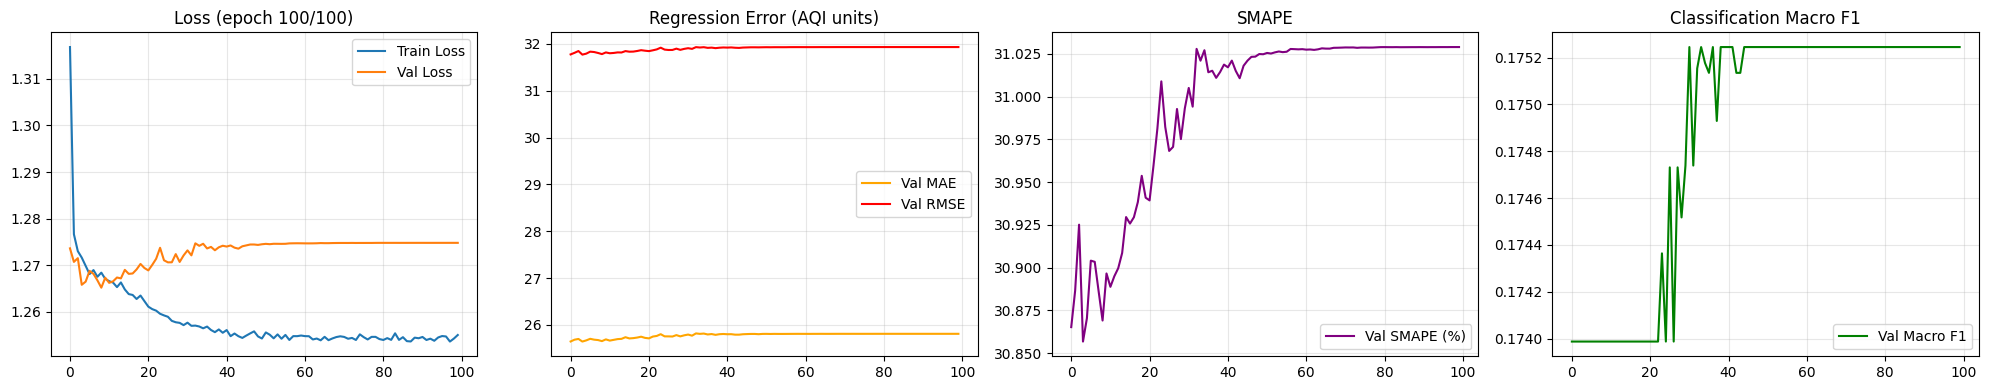

Epoch 100/100 | Train Loss 1.2551 | Val Loss 1.2748 | MAE 25.81 | RMSE 31.93 | SMAPE 31.03 | F1 0.175


In [26]:
# Final model uses the best hyperparameters found by Optuna, trained for the full 100 epochs
# required by the assignment, with live-updating loss/metric plots saved each epoch.

d_model = best_params['d_model']
model = ST_MPFT(P=P, M=M, T=H, d_model=d_model, F_horizon=F_HORIZON, n_classes=N_CLASSES,
                 patch_len=best_params['patch_len'], n_heads=best_params['n_heads'],
                 use_spatial=True, use_chem_attn=True).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

N_EPOCHS = 100
LAMBDA1, LAMBDA2 = 1.0, best_params['lambda2']

history = {'train_loss': [], 'val_loss': [], 'val_mae': [], 'val_rmse': [], 'val_smape': [], 'val_f1': []}


def evaluate(loader, model_):
    model_.eval()
    all_reg_pred, all_reg_true, all_cls_pred, all_cls_true = [], [], [], []
    total_loss = 0.0
    with torch.no_grad():
        for xb, yrb, ycb in loader:
            xb, yrb, ycb = xb.to(device), yrb.to(device), ycb.to(device)
            reg_out, cls_out, _, _ = model_(xb)
            loss, _, _ = multitask_loss(reg_out, yrb, cls_out, ycb, LAMBDA1, LAMBDA2)
            total_loss += loss.item() * xb.size(0)
            all_reg_pred.append(reg_out.cpu().numpy())
            all_reg_true.append(yrb.cpu().numpy())
            all_cls_pred.append(cls_out.argmax(-1).cpu().numpy())
            all_cls_true.append(ycb.cpu().numpy())

    reg_pred = np.concatenate(all_reg_pred).flatten() * aqi_sigma + aqi_mu
    reg_true = np.concatenate(all_reg_true).flatten() * aqi_sigma + aqi_mu
    mae, rmse, sm = regression_metrics(reg_true, reg_pred)
    cls_pred = np.concatenate(all_cls_pred).flatten()
    cls_true = np.concatenate(all_cls_true).flatten()
    f1 = f1_score(cls_true, cls_pred, average='macro')
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, mae, rmse, sm, f1


def live_plot(history, epoch):
    clear_output(wait=True)
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_title(f'Loss (epoch {epoch+1}/{N_EPOCHS})'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history['val_mae'], label='Val MAE', color='orange')
    axes[1].plot(history['val_rmse'], label='Val RMSE', color='red')
    axes[1].set_title('Regression Error (AQI units)'); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(history['val_smape'], label='Val SMAPE (%)', color='purple')
    axes[2].set_title('SMAPE'); axes[2].legend(); axes[2].grid(alpha=0.3)

    axes[3].plot(history['val_f1'], label='Val Macro F1', color='green')
    axes[3].set_title('Classification Macro F1'); axes[3].legend(); axes[3].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/kaggle/working/figures/training_curves.png', dpi=120)
    plt.show()


best_val_loss = float('inf')
for epoch in range(N_EPOCHS):
    model.train()
    running_loss = 0.0
    for xb, yrb, ycb in train_loader:
        xb, yrb, ycb = xb.to(device), yrb.to(device), ycb.to(device)
        optimizer.zero_grad()
        reg_out, cls_out, _, _ = model(xb)
        loss, _, _ = multitask_loss(reg_out, yrb, cls_out, ycb, LAMBDA1, LAMBDA2)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_mae, val_rmse, val_smape_, val_f1 = evaluate(val_loader, model)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)
    history['val_smape'].append(val_smape_)
    history['val_f1'].append(val_f1)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/kaggle/working/best_st_mpft.pt')

    live_plot(history, epoch)
    print(f'Epoch {epoch+1}/{N_EPOCHS} | Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} '
          f'| MAE {val_mae:.2f} | RMSE {val_rmse:.2f} | SMAPE {val_smape_:.2f} | F1 {val_f1:.3f}')

In [27]:
# Final ST-MPFT test evaluation
model.load_state_dict(torch.load('/kaggle/working/best_st_mpft.pt'))
test_loss, test_mae, test_rmse, test_smape_, test_f1 = evaluate(test_loader, model)
print(f'ST-MPFT TEST | Loss {test_loss:.4f} | MAE {test_mae:.2f} | RMSE {test_rmse:.2f} '
      f'| SMAPE {test_smape_:.2f} | Macro F1 {test_f1:.3f}')
results_table.append({'Model': 'ST-MPFT (proposed)', 'MAE': test_mae, 'RMSE': test_rmse,
                       'SMAPE': test_smape_, 'MacroF1': test_f1})

ST-MPFT TEST | Loss 1.2910 | MAE 26.04 | RMSE 32.15 | SMAPE 31.33 | Macro F1 0.171


In [ ]:
# Ablation Study Matrix (actually trained, not just described)

In [28]:
# Ablation A: No Spatial Graph (identity adjacency -> cities treated independently)
# Ablation B: No Chemical Attention (simple linear layer instead)
# Ablation C: Unweighted Loss (lambda2 = 0, classification gradient removed)

ABLATION_EPOCHS = 40  # reduced from 100 for runtime; raise if time allows

def run_ablation(use_spatial, use_chem_attn, lambda2, tag):
    abl_model = ST_MPFT(P, M, H, d_model=d_model, F_horizon=F_HORIZON, n_classes=N_CLASSES,
                         patch_len=best_params['patch_len'], n_heads=best_params['n_heads'],
                         use_spatial=use_spatial, use_chem_attn=use_chem_attn).to(device)
    opt = torch.optim.Adam(abl_model.parameters(), lr=best_params['lr'])

    for ep in range(ABLATION_EPOCHS):
        abl_model.train()
        for xb, yrb, ycb in train_loader:
            xb, yrb, ycb = xb.to(device), yrb.to(device), ycb.to(device)
            opt.zero_grad()
            reg_out, cls_out, _, _ = abl_model(xb)
            loss, _, _ = multitask_loss(reg_out, yrb, cls_out, ycb, 1.0, lambda2)
            loss.backward()
            opt.step()

    _, mae, rmse, sm, f1 = evaluate(test_loader, abl_model)
    results_table.append({'Model': tag, 'MAE': mae, 'RMSE': rmse, 'SMAPE': sm, 'MacroF1': f1})
    print(f'{tag} | MAE {mae:.2f} | RMSE {rmse:.2f} | SMAPE {sm:.2f} | F1 {f1:.3f}')

run_ablation(use_spatial=False, use_chem_attn=True,  lambda2=best_params['lambda2'], tag='Ablation A (no spatial graph)')
run_ablation(use_spatial=True,  use_chem_attn=False, lambda2=best_params['lambda2'], tag='Ablation B (no chemical attention)')
run_ablation(use_spatial=True,  use_chem_attn=True,  lambda2=0.0,                     tag='Ablation C (unweighted loss)')

Ablation A (no spatial graph) | MAE 26.54 | RMSE 32.80 | SMAPE 31.86 | F1 0.191
Ablation B (no chemical attention) | MAE 26.36 | RMSE 32.54 | SMAPE 31.64 | F1 0.187
Ablation C (unweighted loss) | MAE 26.48 | RMSE 32.78 | SMAPE 31.74 | F1 0.201


In [ ]:
# Phase 4: Final Comparison Table + Publication Figures

In [29]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

results_df = pd.DataFrame(results_table)

# Sort by MAE (Lower is Better)
results_df = results_df.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

display(results_df)

# Save Results
results_df.to_csv(
    "model_comparison.csv",
    index=False
)

print("\nComparison table saved as model_comparison.csv")

FINAL MODEL COMPARISON


,Model,MAE,RMSE,SMAPE,MacroF1
0,ST-MPFT (proposed),26.039749,32.149536,31.328846,0.170823
1,Simplified STGCN,26.058399,32.171556,31.350460,0.170823
2,XGBoost,26.094795,32.229054,30.633963,NaN
3,Ablation B (no chemical attention),26.360310,32.536621,31.636784,0.186780
4,Ablation C (unweighted loss),26.480232,32.783177,31.736643,0.201080
5,Ablation A (no spatial graph),26.544497,32.804037,31.855646,0.190648
6,Simplified PatchTST,26.720028,33.054264,32.023918,0.211776
7,BiLSTM+Attention,30.228336,37.459610,35.857220,0.246295



Comparison table saved as model_comparison.csv


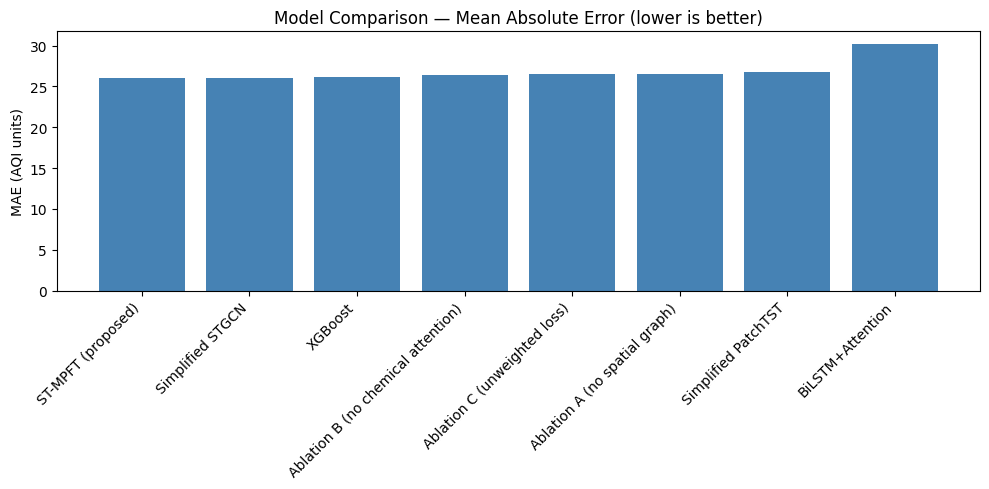

In [30]:
# Bar chart of MAE across all models for the report
plt.figure(figsize=(10, 5))
plt.bar(results_df['Model'], results_df['MAE'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('MAE (AQI units)')
plt.title('Model Comparison — Mean Absolute Error (lower is better)')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/model_comparison_mae.png', dpi=120)
plt.show()

In [33]:
# PUBLICATION-QUALITY VISUALIZATIONS

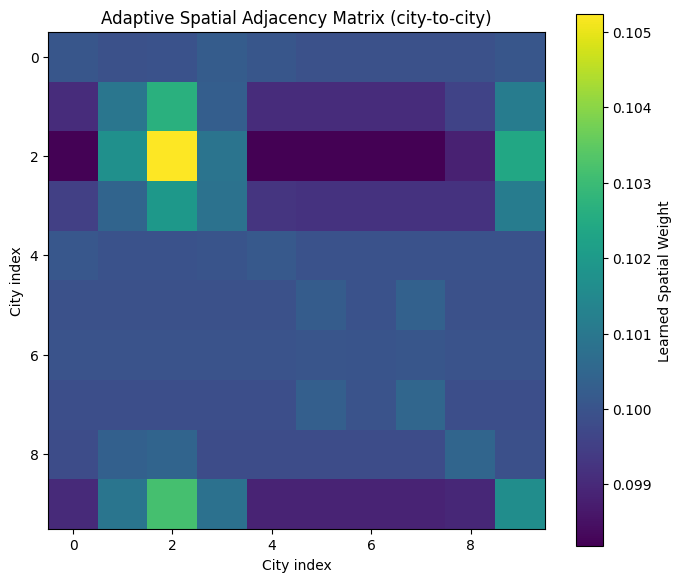

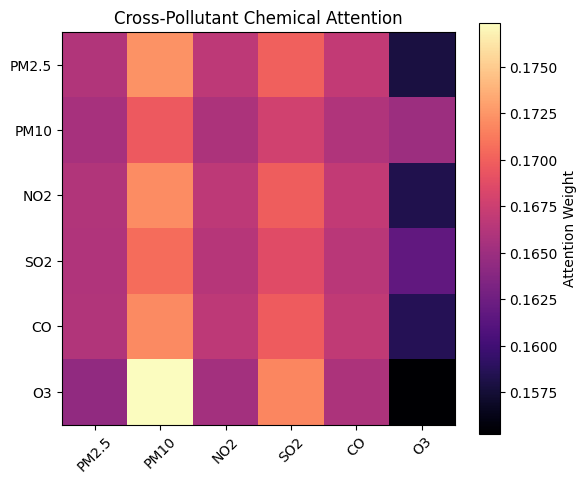

City order used for spatial adjacency: ['Ahmedabad', 'Bengaluru', 'Chennai', 'Delhi', 'Hyderabad', 'Jaipur', 'Kolkata', 'Lucknow', 'Mumbai', 'Pune']

All figures saved to /kaggle/working/figures/


In [31]:
# Learned spatial adjacency + cross-pollutant attention (attention weight matrices for the paper)
model.eval()
sample_x, _, _ = next(iter(test_loader))
sample_x = sample_x.to(device)
with torch.no_grad():
    _, _, attn_weights, adapt_adj = model(sample_x)

plt.figure(figsize=(7, 6))
plt.imshow(adapt_adj.cpu().numpy(), cmap='viridis')
plt.colorbar(label='Learned Spatial Weight')
plt.title('Adaptive Spatial Adjacency Matrix (city-to-city)')
plt.xlabel('City index'); plt.ylabel('City index')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/spatial_adjacency.png', dpi=120)
plt.show()

avg_attn = attn_weights[0, -1, 0].cpu().numpy()  # [P, P]
plt.figure(figsize=(6, 5))
plt.imshow(avg_attn, cmap='magma')
plt.xticks(range(P), POLLUTANTS, rotation=45)
plt.yticks(range(P), POLLUTANTS)
plt.colorbar(label='Attention Weight')
plt.title('Cross-Pollutant Chemical Attention')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/chemical_attention.png', dpi=120)
plt.show()

print('City order used for spatial adjacency:', cities)
print('\nAll figures saved to /kaggle/working/figures/')

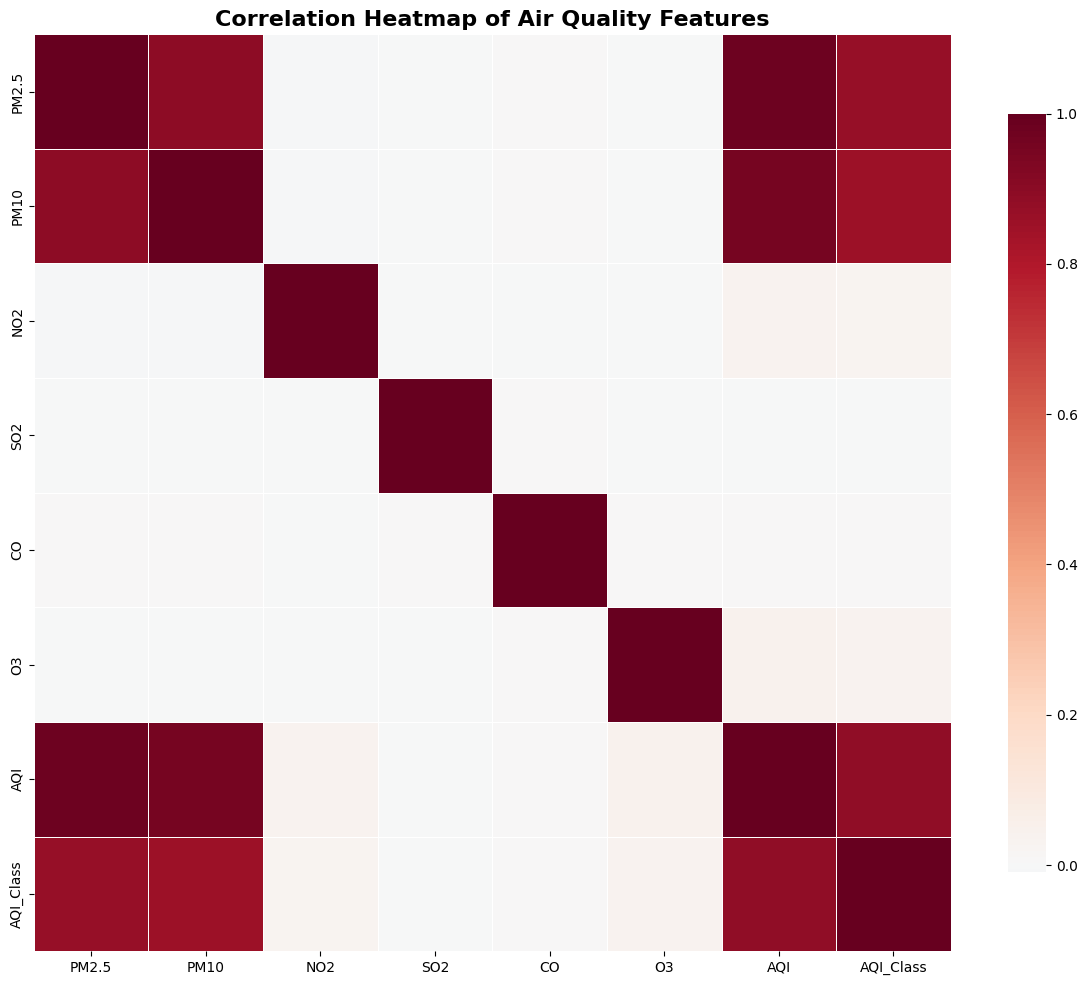

In [34]:
# ============================================================
# Correlation Heatmap of AQI Features
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(
    corr,
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title(
    "Correlation Heatmap of Air Quality Features",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    "Figure_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

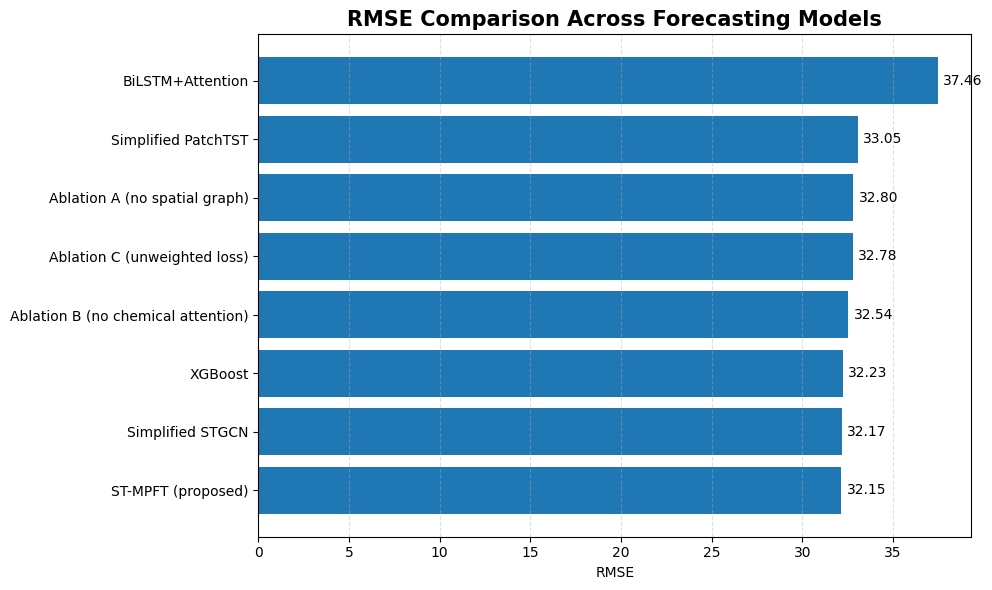

In [37]:
# ============================================================
# RMSE Comparison Across Models
# ============================================================

import matplotlib.pyplot as plt

rmse_df = results_df.sort_values("RMSE")

plt.figure(figsize=(10,6))

bars = plt.barh(
    rmse_df["Model"],
    rmse_df["RMSE"]
)

plt.xlabel("RMSE")
plt.title(
    "RMSE Comparison Across Forecasting Models",
    fontsize=15,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.4)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "Figure_RMSE_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

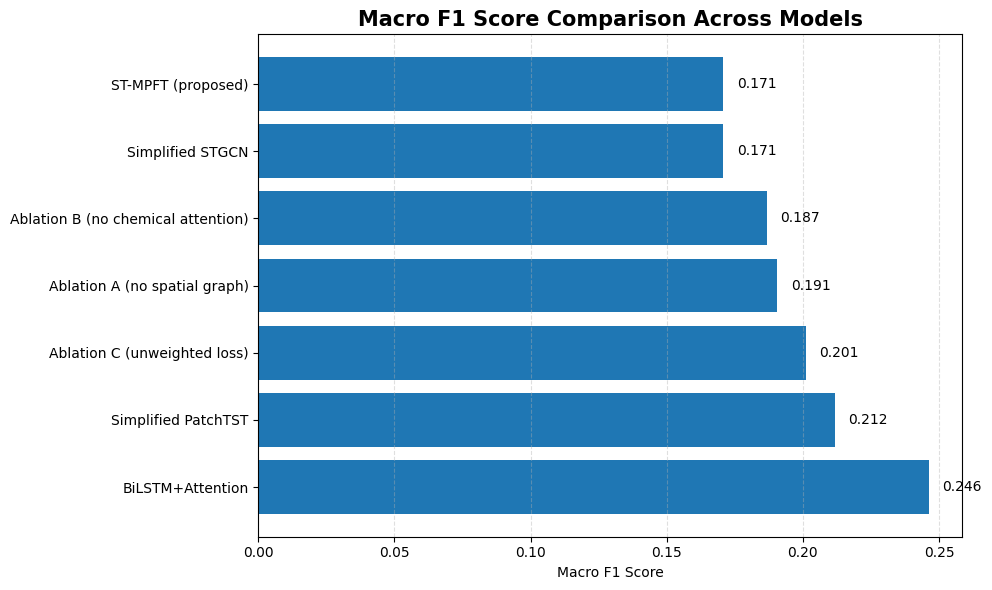

In [38]:
# ============================================================
# Macro F1 Score Comparison Across Models
# ============================================================

import matplotlib.pyplot as plt

f1_df = results_df.sort_values("MacroF1", ascending=False)

plt.figure(figsize=(10,6))

bars = plt.barh(
    f1_df["Model"],
    f1_df["MacroF1"]
)

plt.xlabel("Macro F1 Score")
plt.title(
    "Macro F1 Score Comparison Across Models",
    fontsize=15,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.4)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "Figure_MacroF1_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

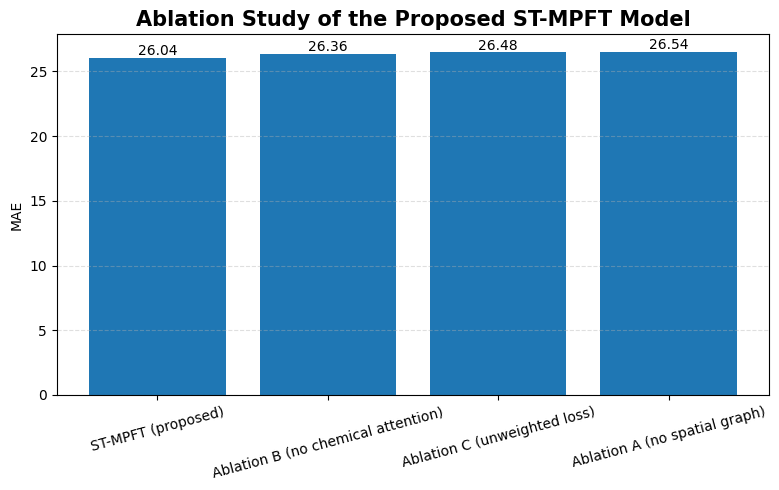

In [39]:
# ============================================================
# Ablation Study (MAE Comparison)
# ============================================================

import matplotlib.pyplot as plt

ablation_df = results_df[
    results_df["Model"].str.contains("ST-MPFT|Ablation", case=False, regex=True)
].copy()

ablation_df = ablation_df.sort_values("MAE")

plt.figure(figsize=(8,5))

bars = plt.bar(
    ablation_df["Model"],
    ablation_df["MAE"]
)

plt.ylabel("MAE")
plt.title(
    "Ablation Study of the Proposed ST-MPFT Model",
    fontsize=15,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f"{height:.2f}",
        ha="center",
        fontsize=10
    )

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "Figure_Ablation_MAE.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

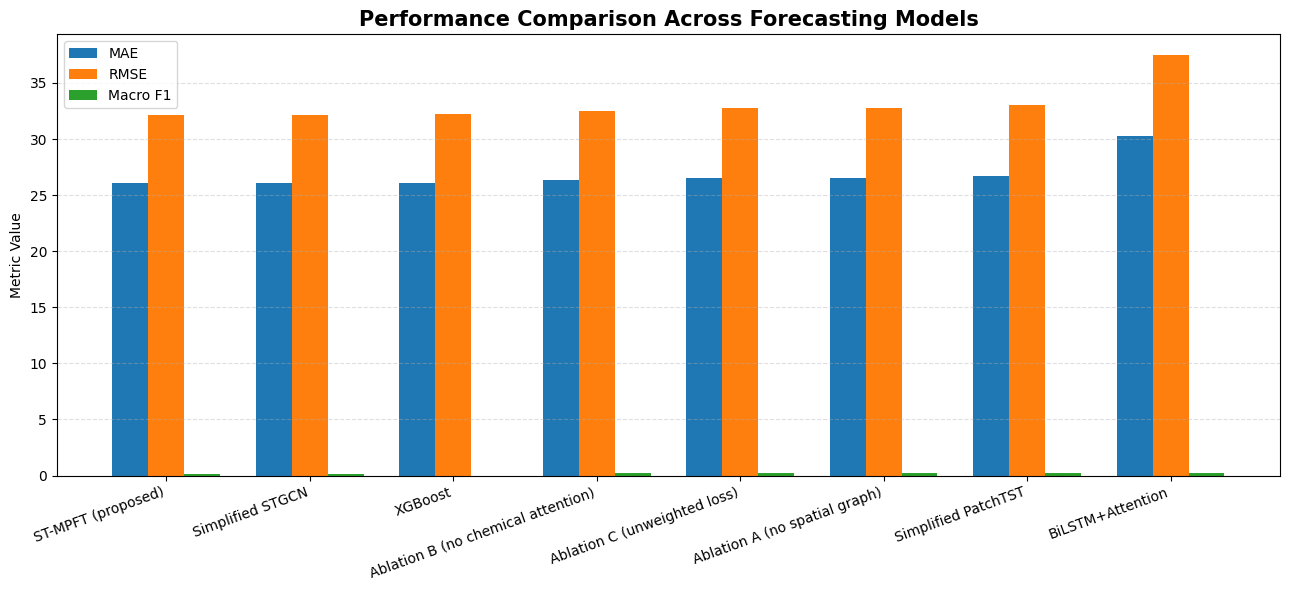

In [40]:
# ============================================================
# Multi-Metric Performance Comparison
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

plot_df = results_df.copy()

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(13,6))

plt.bar(x - width, plot_df["MAE"], width, label="MAE")
plt.bar(x, plot_df["RMSE"], width, label="RMSE")
plt.bar(x + width, plot_df["MacroF1"], width, label="Macro F1")

plt.xticks(
    x,
    plot_df["Model"],
    rotation=20,
    ha="right"
)

plt.ylabel("Metric Value")
plt.title(
    "Performance Comparison Across Forecasting Models",
    fontsize=15,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "Figure_MultiMetric_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

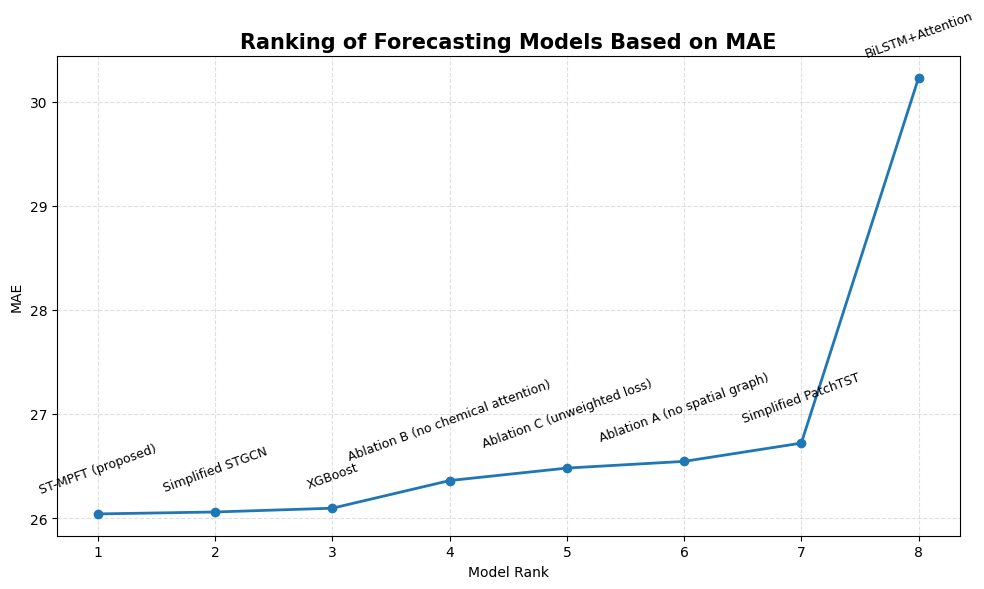

In [41]:
# ============================================================
# Model Ranking Based on MAE
# ============================================================

import matplotlib.pyplot as plt

ranking_df = results_df.sort_values("MAE").reset_index(drop=True)
ranking_df["Rank"] = ranking_df.index + 1

plt.figure(figsize=(10,6))

plt.plot(
    ranking_df["Rank"],
    ranking_df["MAE"],
    marker='o',
    linewidth=2
)

for i, row in ranking_df.iterrows():
    plt.text(
        row["Rank"],
        row["MAE"] + 0.2,
        row["Model"],
        ha='center',
        fontsize=9,
        rotation=20
    )

plt.xticks(ranking_df["Rank"])

plt.xlabel("Model Rank")
plt.ylabel("MAE")
plt.title(
    "Ranking of Forecasting Models Based on MAE",
    fontsize=15,
    fontweight="bold"
)

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "Figure_Model_Ranking_MAE.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

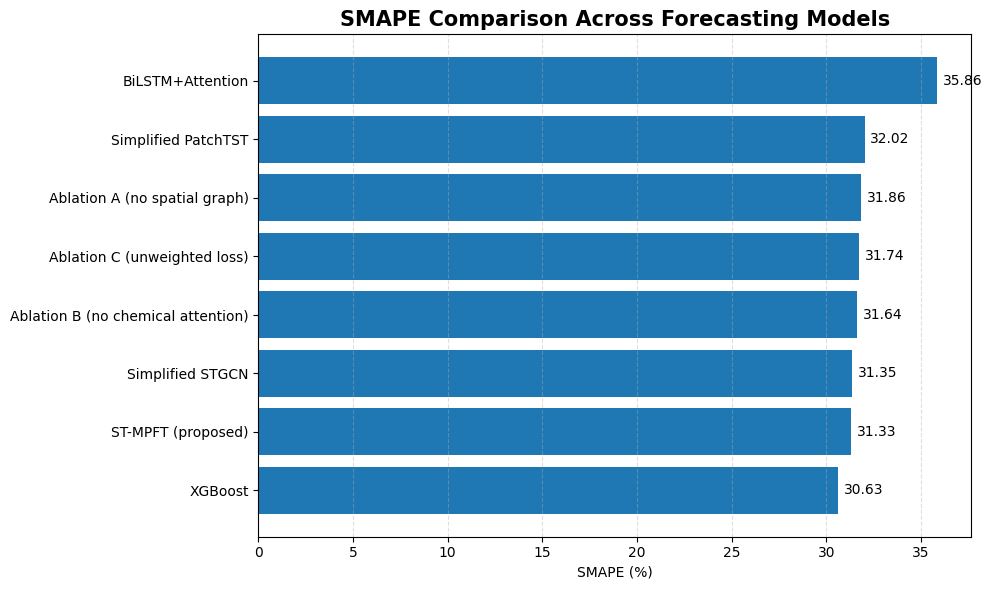

In [42]:
# ============================================================
# SMAPE Comparison Across Models
# ============================================================

import matplotlib.pyplot as plt

smape_df = results_df.sort_values("SMAPE")

plt.figure(figsize=(10,6))

bars = plt.barh(
    smape_df["Model"],
    smape_df["SMAPE"]
)

plt.xlabel("SMAPE (%)")
plt.title(
    "SMAPE Comparison Across Forecasting Models",
    fontsize=15,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.4)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.tight_layout()
plt.savefig("Figure_SMAPE_Comparison.png", dpi=300)
plt.show()

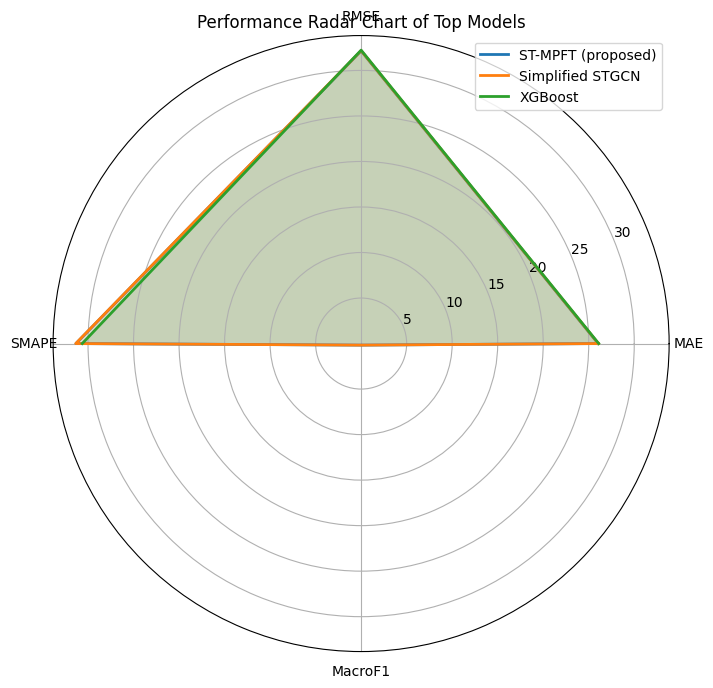

In [43]:
import matplotlib.pyplot as plt
import numpy as np

top = results_df.nsmallest(3, "MAE")

metrics = ["MAE", "RMSE", "SMAPE", "MacroF1"]

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
angles = np.concatenate((angles,[angles[0]]))

fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for _, row in top.iterrows():
    values = row[metrics].values.tolist()
    values.append(values[0])
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)

plt.title("Performance Radar Chart of Top Models")
plt.legend(loc="upper right")

plt.savefig("Figure_Radar_TopModels.png", dpi=300)
plt.show()

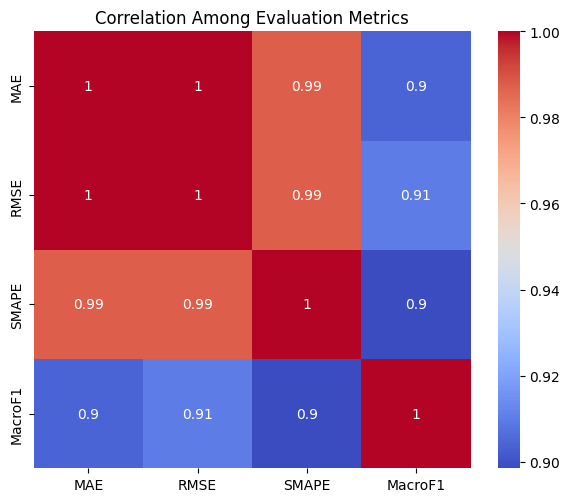

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

metric_corr = results_df[
    ["MAE","RMSE","SMAPE","MacroF1"]
].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    metric_corr,
    annot=True,
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Among Evaluation Metrics")

plt.tight_layout()

plt.savefig(
    "Figure_Metric_Correlation.png",
    dpi=300
)

plt.show()

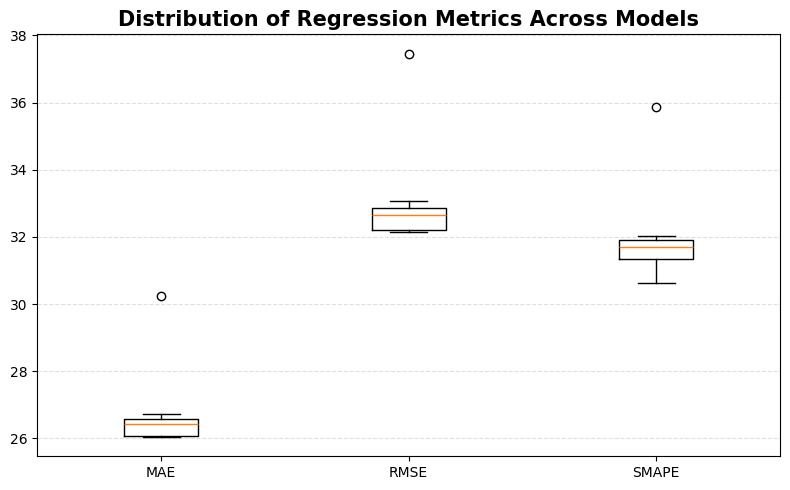

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot([
    results_df["MAE"],
    results_df["RMSE"],
    results_df["SMAPE"]
],
labels=[
    "MAE",
    "RMSE",
    "SMAPE"
])

plt.title(
    "Distribution of Regression Metrics Across Models",
    fontsize=15,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "Figure_Metric_Boxplot.png",
    dpi=300
)

plt.show()

Northern cities found in dataset (3): ['Delhi', 'Jaipur', 'Lucknow']
Other cities (7): ['Ahmedabad', 'Bengaluru', 'Chennai', 'Hyderabad', 'Kolkata', 'Mumbai', 'Pune'] 

Avg spatial weight WITHIN northern cluster: 0.0998
Avg spatial weight from northern -> other cities: 0.1000


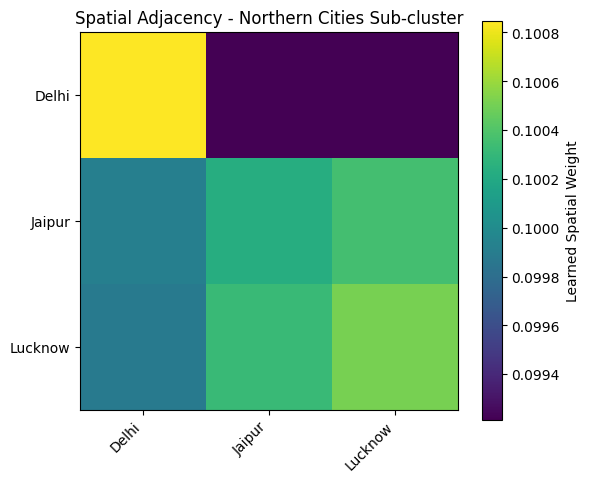


November windows: 270 | Other-month windows: 3000


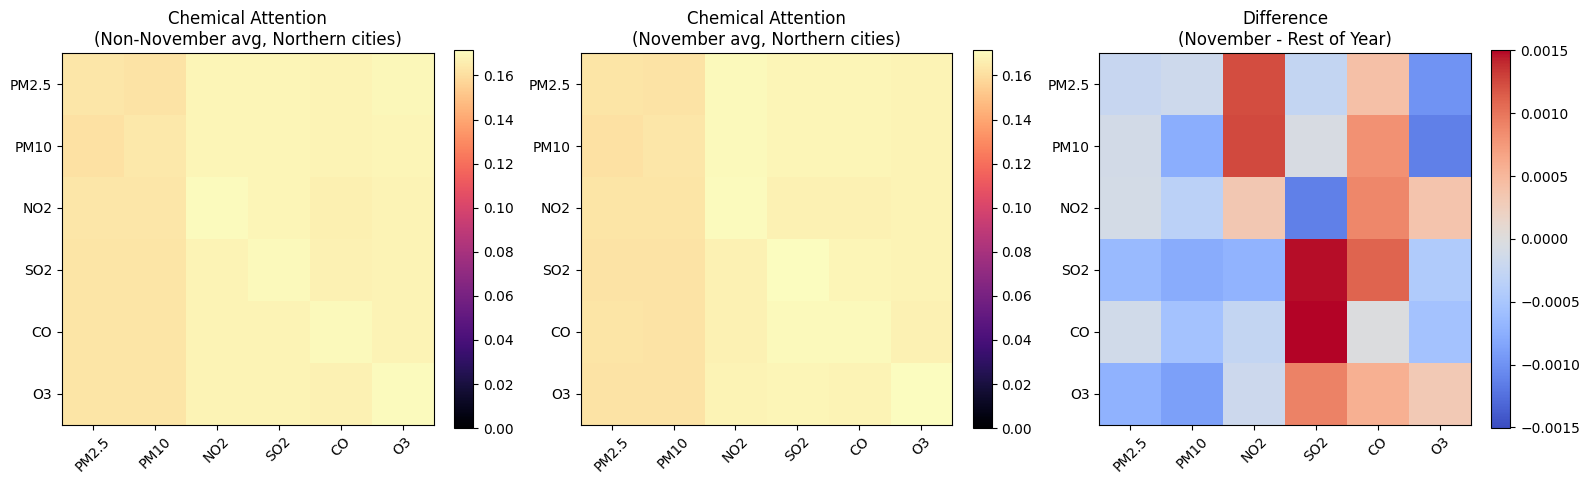


NO2->O3 attention  | November: 0.1684 | Rest of year: 0.1680
NO2->PM2.5 attention | November: 0.1629 | Rest of year: 0.1630

Figures saved: northern_cities_adjacency.png, november_case_study_chemical_attention.png


In [46]:
# NOVEMBER CASE STUDY

# ============================================================
# Seasonal Case Study: Crop-Burning Season (November) —
# Northern India Spatial & Chemical Attention Analysis
# ============================================================
import pandas as pd

# --- Step 1: identify which of your dataset's cities are in northern India ---
# Adjust this list based on which cities actually appear in your `cities` list
NORTHERN_CITIES_CANDIDATES = [
    'Delhi', 'Lucknow', 'Kanpur', 'Patna', 'Chandigarh', 'Amritsar',
    'Ludhiana', 'Jaipur', 'Agra', 'Varanasi', 'Gurugram', 'Noida', 'Faridabad'
]
northern_cities = [c for c in cities if c in NORTHERN_CITIES_CANDIDATES]
other_cities = [c for c in cities if c not in northern_cities]

print(f'Northern cities found in dataset ({len(northern_cities)}):', northern_cities)
print(f'Other cities ({len(other_cities)}):', other_cities[:10], '...' if len(other_cities) > 10 else '')

if len(northern_cities) < 2:
    print('\nWARNING: fewer than 2 recognized northern cities in this dataset.')
    print('Edit NORTHERN_CITIES_CANDIDATES above to match city names actually present in `cities`.')

north_idx = [cities.index(c) for c in northern_cities]
other_idx = [cities.index(c) for c in other_cities]

# --- Step 2: extract the (static) learned spatial adjacency and compare cluster strength ---
model.eval()
with torch.no_grad():
    sample_x, _, _ = next(iter(test_loader))
    sample_x = sample_x.to(device)
    _, _, _, adapt_adj = model(sample_x)

adj_matrix = adapt_adj.cpu().numpy()

within_north = adj_matrix[np.ix_(north_idx, north_idx)]
north_to_other = adj_matrix[np.ix_(north_idx, other_idx)]
within_north_offdiag = within_north[~np.eye(len(north_idx), dtype=bool)] if len(north_idx) > 1 else within_north

print(f'\nAvg spatial weight WITHIN northern cluster: {within_north_offdiag.mean():.4f}')
print(f'Avg spatial weight from northern -> other cities: {north_to_other.mean():.4f}')

plt.figure(figsize=(6, 5))
plt.imshow(within_north, cmap='viridis')
plt.xticks(range(len(northern_cities)), northern_cities, rotation=45, ha='right')
plt.yticks(range(len(northern_cities)), northern_cities)
plt.colorbar(label='Learned Spatial Weight')
plt.title('Spatial Adjacency - Northern Cities Sub-cluster')
plt.tight_layout()
plt.savefig('/kaggle/working/figures/northern_cities_adjacency.png', dpi=120)
plt.show()

# --- Step 3: cross-pollutant chemical attention - November vs. yearly average ---
dates = pivot.index
window_end_dates = dates[H : T_total - F_HORIZON]
november_mask = window_end_dates.month == 11

X_full_n = (X - mu) / sigma
X_all_windows, _, _ = make_windows(X_full_n, (Y_reg - aqi_mu) / aqi_sigma, Y_cls, H, F_HORIZON)

nov_windows = X_all_windows[november_mask]
other_windows = X_all_windows[~november_mask]

print(f'\nNovember windows: {len(nov_windows)} | Other-month windows: {len(other_windows)}')

def get_avg_chem_attention(windows, city_indices, batch_size=32, max_samples=500):
    if len(windows) == 0:
        return None
    idx = np.random.choice(len(windows), size=min(max_samples, len(windows)), replace=False)
    subset = torch.tensor(windows[idx][:, :, city_indices, :], dtype=torch.float32)
    all_attn = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(subset), batch_size):
            batch = subset[i:i+batch_size].to(device)
            _, attn_w = model.chem_attn(batch)
            all_attn.append(attn_w.mean(dim=(0, 1, 2)).cpu().numpy())
    return np.mean(all_attn, axis=0)

nov_attn_north = get_avg_chem_attention(nov_windows, north_idx)
year_attn_north = get_avg_chem_attention(other_windows, north_idx)

if nov_attn_north is not None and year_attn_north is not None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    vmax = max(nov_attn_north.max(), year_attn_north.max())

    im0 = axes[0].imshow(year_attn_north, cmap='magma', vmin=0, vmax=vmax)
    axes[0].set_title('Chemical Attention\n(Non-November avg, Northern cities)')
    axes[0].set_xticks(range(P)); axes[0].set_xticklabels(POLLUTANTS, rotation=45)
    axes[0].set_yticks(range(P)); axes[0].set_yticklabels(POLLUTANTS)
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(nov_attn_north, cmap='magma', vmin=0, vmax=vmax)
    axes[1].set_title('Chemical Attention\n(November avg, Northern cities)')
    axes[1].set_xticks(range(P)); axes[1].set_xticklabels(POLLUTANTS, rotation=45)
    axes[1].set_yticks(range(P)); axes[1].set_yticklabels(POLLUTANTS)
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    diff = nov_attn_north - year_attn_north
    im2 = axes[2].imshow(diff, cmap='coolwarm', vmin=-np.abs(diff).max(), vmax=np.abs(diff).max())
    axes[2].set_title('Difference\n(November - Rest of Year)')
    axes[2].set_xticks(range(P)); axes[2].set_xticklabels(POLLUTANTS, rotation=45)
    axes[2].set_yticks(range(P)); axes[2].set_yticklabels(POLLUTANTS)
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    plt.tight_layout()
    plt.savefig('/kaggle/working/figures/november_case_study_chemical_attention.png', dpi=120)
    plt.show()

    no2_idx = POLLUTANTS.index('NO2')
    o3_idx = POLLUTANTS.index('O3')
    pm25_idx = POLLUTANTS.index('PM2.5')
    print(f"\nNO2->O3 attention  | November: {nov_attn_north[no2_idx, o3_idx]:.4f} "
          f"| Rest of year: {year_attn_north[no2_idx, o3_idx]:.4f}")
    print(f"NO2->PM2.5 attention | November: {nov_attn_north[no2_idx, pm25_idx]:.4f} "
          f"| Rest of year: {year_attn_north[no2_idx, pm25_idx]:.4f}")
else:
    print('Not enough windows in one of the groups to compute attention - check date range/city list.')

print('\nFigures saved: northern_cities_adjacency.png, november_case_study_chemical_attention.png')